Exercise 4: NumPy Array Operations

In [16]:
#Creating a 5X5 matrix
import numpy as np

matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0
print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [17]:
#Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Mean of each column:", normalized.mean(axis=0))
print("Std of each column:", normalized.std(axis=0))

Mean of each column: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Std of each column: [1. 1. 1.]


In [18]:
#Implementing a linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated:", theta_hat)
print("True:", true_theta)

Estimated: [ 2.51723721 -1.19783796  3.72399266]
True: [ 2.5 -1.2  3.7]


Exercise 5: Pandas Data Analysis

In [20]:
#code snippet
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [21]:
#Task 1 -Data Cleaning and Exploration

# Basic info
print(df.info())
print(df.describe())

# Count missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing exam_score with mean for that student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

# Fill missing hours_studied with median for that student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

print("Missing after filling:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

In [22]:
#Task 2- Analysis

# Average exam_score by major
avg_by_major = df.groupby('major')['exam_score'].mean()
print(avg_by_major)

# Major with highest average
print("Highest:", avg_by_major.idxmax())

# Correlation between hours_studied and exam_score
print("Correlation:", df['hours_studied'].corr(df['exam_score']))

# Performance category column
df['performance'] = pd.cut(df['exam_score'],
    bins=[-np.inf, 70, 80, 90, np.inf],
    labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])
print(df['performance'].value_counts())

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Highest: CS
Correlation: -0.05598138347292439
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [23]:
#Task 3-Advanced Analysis

# Stats per major + year combination
summary = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)
print(summary)

# Top 5 by exam_score (keep='all' keeps tied students)
print(df.nlargest(5, 'exam_score', keep='all'))

# Pivot table: major (rows) x year (columns)
pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print(pivot)

              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13       76.570059          12.677806
        2               12       74.899613          13.426372
        3               14       80.178476          14.486815
        4               15       70.697689          14.253944
CS      1               12       77.098194          13.039480
        2                7       76.155936          13.995784
        3                9       72.347626          15.039892
        4               18       78.119997          16.275541
Math    1               11       74.053167          19.001215
        2                9       81.226714          12.345468
        3               10       72.017537          15.175871
        4               16       73.103066          17.419175
Physics 1               13       77.828686          13.489911
        2               12       73.277734          14.616778
        

Exercise 6: Data Visualization

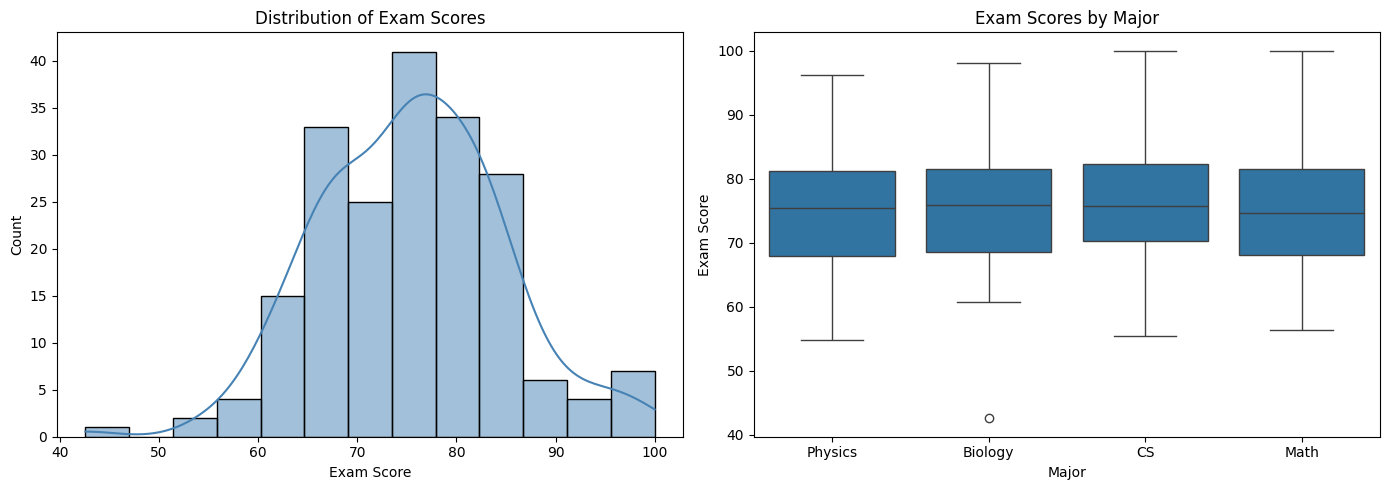

In [24]:
#Task 1-Distribution Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(df['exam_score'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


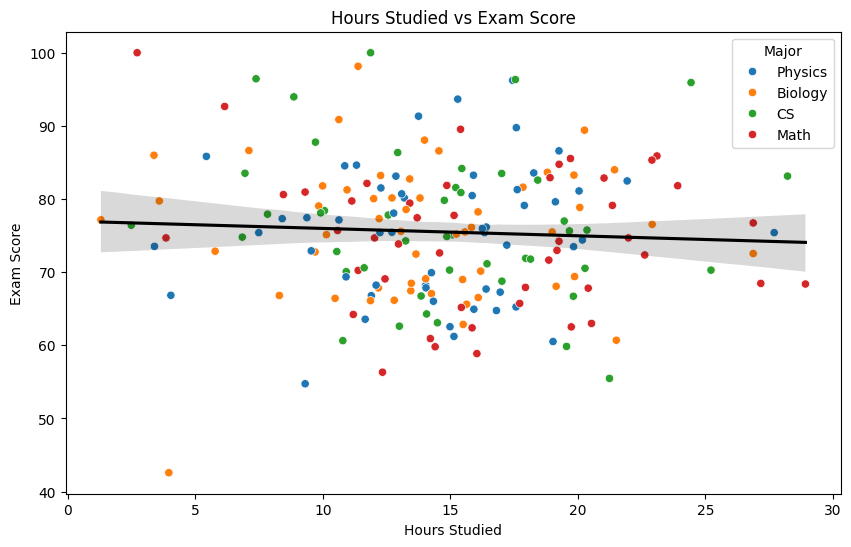

In [25]:
#Task 2- Relationship Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Code from cell A40RrJ6JZf3v to create df
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Code from cell nseE6V9AcHy4 to preprocess df
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

# Original plotting code
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')

sns.regplot(data=df, x='hours_studied', y='exam_score',
            scatter=False, color='black')

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()

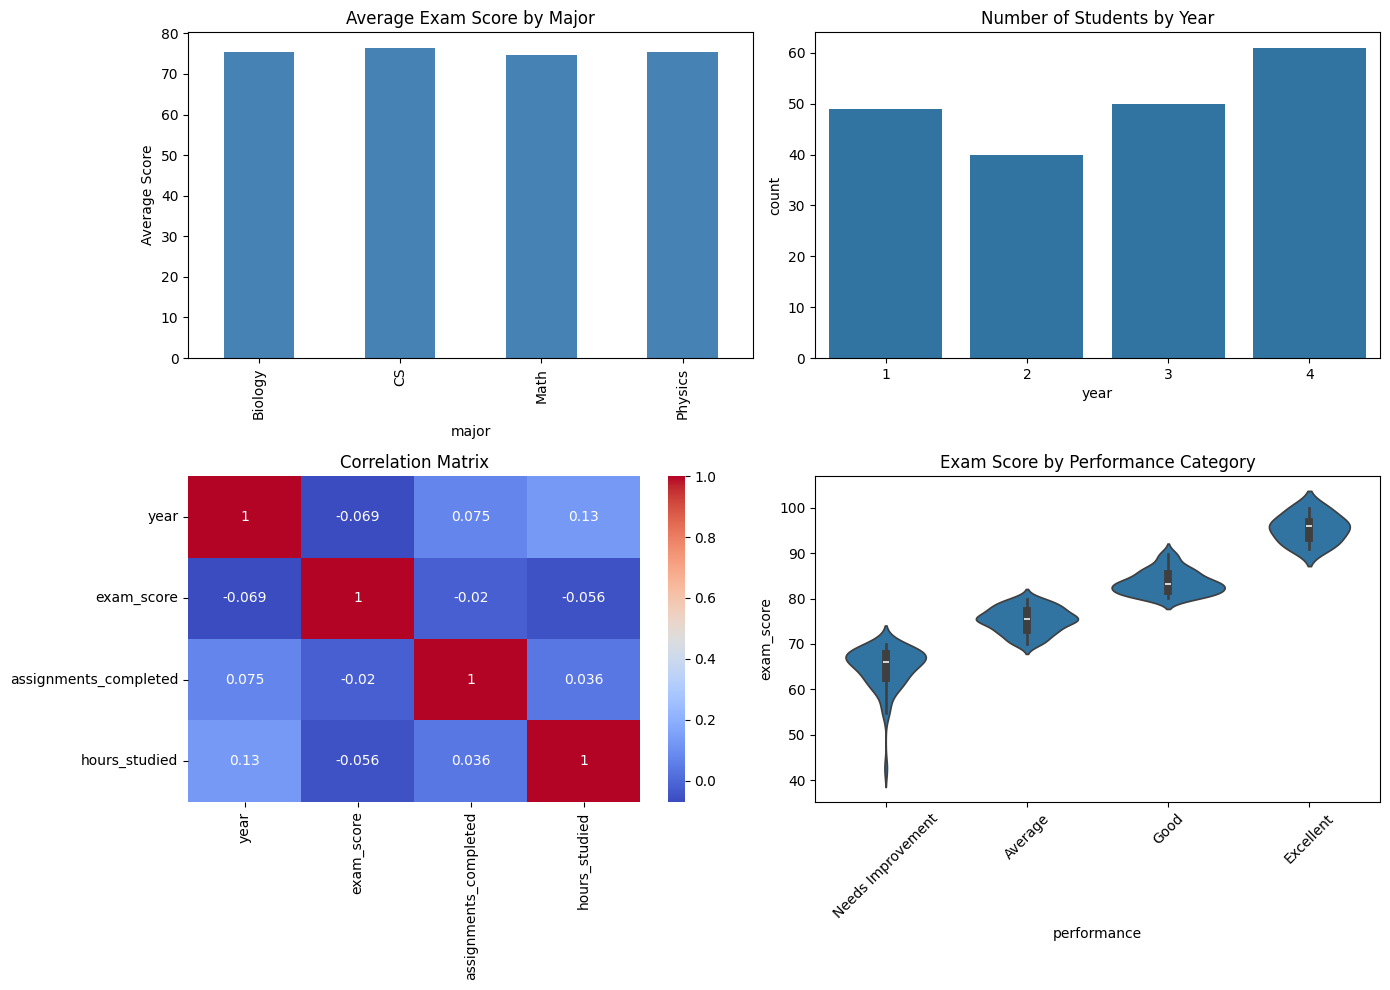

In [13]:
##Task 3-Advanced dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


df.groupby('major')['exam_score'].mean().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_ylabel('Average Score')


sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title('Number of Students by Year')


numeric_cols = df.select_dtypes(include=np.number).drop(columns='student_id')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')


sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Exercise 7: Integration Challenge

In [15]:
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})



In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# CLV
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency']
                    * customers['avg_purchase_value']
                    * (1 + customers['churn_risk']))

# Age groups
customers['age_group'] = pd.cut(customers['age'],
    bins=[17, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'])

 Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
